<a href="https://colab.research.google.com/github/Seanm18/Portafolio/blob/main/predictor_casas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

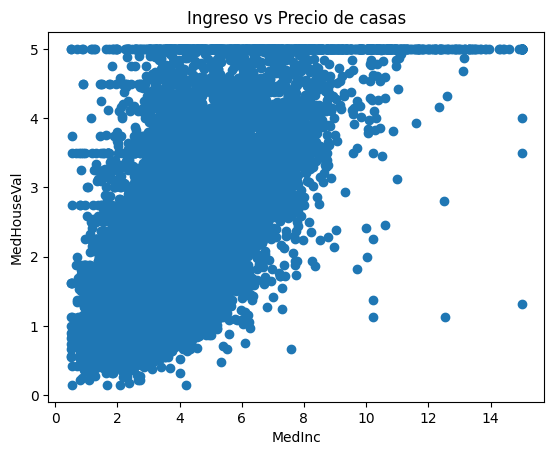

Error promedio: $32,754
Precisión (R²): 80.51%
[4.3199541]


In [ ]:

#1.importa las librias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

#2.Cargar datos
data = fetch_california_housing(as_frame=True)
df = data.frame

#3. Explorar los datos
df.describe()
df.head()
df.shape

#4. visualizar los datos

x = 'MedInc'
y = 'MedHouseVal'

plt.title('Ingreso vs Precio de casas')
plt.scatter(df[x], df[y])
plt.xlabel(x)
plt.ylabel(y)
plt.show()

#5.Entrenar modelo

x = df.drop('MedHouseVal', axis=1) #borramos la columna de precio, ya que Y lo tiene
y = df['MedHouseVal']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(x_train, y_train)


#6. Evaluar el modelo
predicciones = model.predict(x_test)

mae = mean_absolute_error(y_test, predicciones)
r2 = r2_score(y_test, predicciones)

print(f"Error promedio: ${mae*100000:,.0f}")
print(f"Precisión (R²): {r2:.2%}")


#7. Predecir una casa nueva

casa_nueva = pd.DataFrame({
    'MedInc': [8.3252],
    'HouseAge': [41.0],
    'AveRooms': [6.9841],
    'AveBedrms': [1.0833],
    'Population': [322.0],
    'AveOccup': [2.55],
    'Latitude': [37.88],
    'Longitude': [-122.23]
})

print(model.predict(casa_nueva))
